## Project 2
 
### Instructions
Identify a large 2-node network dataset—you can start with a dataset in a repository. Your data should meet the criteria that it consists of ties between and not within two (or more) distinct groups.
- Reduce the size of the network using a method such as the island method described in chapter 4 of social network analysis.
- What can you infer about each of the distinct groups?
- You may work in a small group on the project.

Your code and analysis should be delivered in an IPython Notebook by end of day Monday 

### beginning importing relevant libs and then the extracted data

In [1]:
import pandas as pd
import networkx as nx
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

In [2]:
## I Manually downloaded the movies data set from here: https://snap.stanford.edu/data/web-Movies.html
## Once downloaded i unzipped the folder, extracted the data and moved the text file to my local working directory. 
## I added that file to the gitignore files within the repo to prevent pushing errors.
raw_file = "movies.txt"

In [3]:
def parse_amazon_reviews_txt(raw_file, limit=None):
    reviews = []
    review = {}

    with open(raw_file, "r", encoding="utf-8", errors="ignore") as f:
        for line in tqdm(f):
            line = line.strip()

            # blank line = end of one review block
            if line == "":
                if review:
                    reviews.append(review)
                    review = {}
                    if limit is not None and len(reviews) >= limit:
                        break
                continue

            if ":" in line:
                key, value = line.split(":", 1)
                review[key.strip()] = value.strip()

    # catch final review if file doesn't end with blank line
    if review and (limit is None or len(reviews) < limit):
        reviews.append(review)

    return pd.DataFrame(reviews)

In [6]:
##limiting to first 200,000 rows for computer memory. We're using above parsing function to read the data into a df. 
## NOte this isnt a random sample. Just firstr 200k rows, so just making the data workable for this preoject. 
df = parse_amazon_reviews_txt(raw_file, limit=200000)
df.head()

0it [00:00, ?it/s]

,product/productId,review/userId,review/profileName,review/helpfulness,review/score,review/time,review/summary,review/text
0,B003AI2VGA,A141HP4LYPWMSR,"Brian E. Erland ""Rainbow Sphinx""",7/7,3.0,1182729600,"""There Is So Much Darkness Now ~ Come For The ...","Synopsis: On the daily trek from Juarez, Mexic..."
1,B003AI2VGA,A328S9RN3U5M68,Grady Harp,4/4,3.0,1181952000,Worthwhile and Important Story Hampered by Poo...,THE VIRGIN OF JUAREZ is based on true events s...
2,B003AI2VGA,A1I7QGUDP043DG,"Chrissy K. McVay ""Writer""",8/10,5.0,1164844800,This movie needed to be made.,The scenes in this film can be very disquietin...
3,B003AI2VGA,A1M5405JH9THP9,golgotha.gov,1/1,3.0,1197158400,distantly based on a real tragedy,THE VIRGIN OF JUAREZ (2006)<br />directed by K...
4,B003AI2VGA,ATXL536YX71TR,"KerrLines ""&#34;Movies,Music,Theatre&#34;""",1/1,3.0,1188345600,"""What's going on down in Juarez and shining a ...","Informationally, this SHOWTIME original is ess..."


In [8]:
### Limiting to the relevant colummns needed for analysis, 
print(df.shape)
## Separate DF to work with 
df_limited = df[["product/productId","review/userId","review/score","review/time","review/summary"]].copy()

#renaming columnns
df_limited.columns = ["movie", "user", "rating", "time", "summary"]
df_limited.head()

## Removing those that have nulls for the movie id or the user (precautionary)
df_limited = df_limited.dropna(subset=["movie", "user"])
## Also droping the unknown values for users
df_limited = df_limited[df_limited["user"].str.lower() != "unknown"]

## Convering to numeric values
df_limited["rating"] = pd.to_numeric(df_limited["rating"], errors="coerce")
df_limited["time"] = pd.to_numeric(df_limited["time"], errors="coerce")

#Resulting Shape and takign a look
print(df_limited.shape)
df_limited.head()

(200000, 8)
(200000, 5)


,movie,user,rating,time,summary
0,B003AI2VGA,A141HP4LYPWMSR,3.0,1182729600,"""There Is So Much Darkness Now ~ Come For The ..."
1,B003AI2VGA,A328S9RN3U5M68,3.0,1181952000,Worthwhile and Important Story Hampered by Poo...
2,B003AI2VGA,A1I7QGUDP043DG,5.0,1164844800,This movie needed to be made.
3,B003AI2VGA,A1M5405JH9THP9,3.0,1197158400,distantly based on a real tragedy
4,B003AI2VGA,ATXL536YX71TR,3.0,1188345600,"""What's going on down in Juarez and shining a ..."


In [9]:
## OFfically looking at the stats in our workign df
print("Number of reviews:", len(df_limited))
print("Unique users:", df_limited["user"].nunique())
print("Unique movies:", df_limited["movie"].nunique())

df_limited["rating"].value_counts().sort_index()

Number of reviews: 200000
Unique users: 115605
Unique movies: 6156


rating
1.0     16691
2.0     11997
3.0     20472
4.0     42075
5.0    108765
Name: count, dtype: int64

In [11]:
### beginning on making this a network db
movies_network = nx.Graph()
users = df_limited["user"].unique()
movies = df_limited["movie"].unique()

movies_network.add_nodes_from(users, bipartite="users")
movies_network.add_nodes_from(movies, bipartite="movies")

edges = list(zip(df_limited["user"], df_limited["movie"]))
movies_network.add_edges_from(edges)

print("Nodes:", movies_network.number_of_nodes())
print("Edges:", movies_network.number_of_edges())

Nodes: 121761
Edges: 198117


In [12]:
## Starting by separating the two main groups of nodes the users and the movies 
user_nodes = {n for n, d in movies_network.nodes(data=True) if d["bipartite"] == "users"}
movie_nodes = {n for n, d in movies_network.nodes(data=True) if d["bipartite"] == "movies"}

print("User nodes:", len(user_nodes))
print("Movie nodes:", len(movie_nodes))

User nodes: 115605
Movie nodes: 6156


In [14]:
### limting to top ten users based on the number of reviews.
top_users = sorted(movies_network.degree(user_nodes), key=lambda x: x[1], reverse=True)[:10]
top_users

[('ANCOMAI0I7LVG', 252),
 ('A3LZGLA88K0LA0', 244),
 ('A16CZRQL23NOIW', 226),
 ('ABO2ZI2Y5DQ9T', 218),
 ('A2NJO6YE954DBH', 212),
 ('A328S9RN3U5M68', 192),
 ('A35ZK3M8L9JUPX', 186),
 ('A10ODC971MDHV8', 182),
 ('A39CX0EE4BZCZC', 176),
 ('AJKWF4W7QD4NS', 175)]

In [15]:
### limting to top ten movies based on the number of reviews received by users.
top_movies = sorted(movies_network.degree(movie_nodes), key=lambda x: x[1], reverse=True)[:10]
top_movies

[('B002LBKDYE', 876),
 ('B004WO6BPS', 831),
 ('B009NQKPUW', 812),
 ('B001N4RORE', 783),
 ('B001VNWB5W', 769),
 ('7883704540', 767),
 ('B000VBJEFK', 767),
 ('B0028OA3EY', 727),
 ('B0028OA3EO', 727),
 ('B008PZZND6', 702)]

##### For the sake of this project the movie rating number will be used as the weight for the Island Reduction Methodology

In [20]:
# Build a weighted using rating as edge weight
movies_network_weighted = nx.Graph()

# Add the two groups of nodes
movies_network_weighted.add_nodes_from(df_limited["user"].unique(), bipartite="users")
movies_network_weighted.add_nodes_from(df_limited["movie"].unique(), bipartite="movies")

# using the rating that the user provided to the movie as the edge weight
for i, row in df_limited.iterrows():
    movies_network_weighted.add_edge(row["user"], row["movie"], weight=row["rating"])

print("Weighted network nodes:", movies_network_weighted.number_of_nodes())
print("Weighted network edges:", movies_network_weighted.number_of_edges())

Weighted network nodes: 121761
Weighted network edges: 198117


In [21]:
## Establishing the minimum "weight", actually a minmum rating, i would like to keep for my reduction 
min_weight = 4 

# Applying this limit for island based reduction method
limit_red_graph = nx.Graph()

# Copy all nodes and their bipartite labels over to new network.
limit_red_graph.add_nodes_from(movies_network_weighted.nodes(data=True))

# filter out those with a weight /rating under 4 wuith a list
strong_edges = [
    (u, v, d)
    for u, v, d in movies_network_weighted.edges(data=True)
    if d.get("weight", 0) >= min_weight
]
limit_red_graph.add_edges_from(strong_edges)

# Dropping the nodes that now have no connections via edges
limit_red_graph.remove_nodes_from(list(nx.isolates(limit_red_graph)))

In [39]:
### Now we have the limited "islands" after that >=4 rating weight was applied.
## Looking at the remaining "islands" after the reduction
islands = list(nx.connected_components(limit_red_graph))
largest = max((len(c) for c in islands), default=0)

print("Nodes:", limit_red_graph.number_of_nodes())
print("Edges:", limit_red_graph.number_of_edges())
print("Number of islands:", len(islands))
print("Largest island size:", largest)

ERROR! Session/line number was not unique in database. History logging moved to new session 59
Nodes: 98199
Edges: 149286
Number of islands: 1571
Largest island size: 92516


In [ ]:
island_sizes = sorted([len(comp) for comp in islands], reverse=True)
print("Top 10 island sizes:", island_sizes[:10])

#### There is one massive island and a bunch of straglers that of much smaller size. This implies that the 4 or over movie ratings are mostly in a pretty large connected network, with 1570 other smaller islands Resulting from this limitation. The rating 4 may actually be a bit too low for the first island to be broken up. Continuing on if we maintain that a 4 or above is a "high" rating, it can be said that movies that are highly rated share the same users rating them. While for the user side of things, there is overlap in the movies those users rate highly- Movies with more mass appeal. THe trsailing smaller island, which are at a count of 1570, signify more of a niche taste in movies, less "mainstream" appeal. 

In [41]:
### Divingin ot the top 10 islands, and their respective dimensions. 
island_summary = []
for i, comp in enumerate(sorted(islands, key=len, reverse=True), start=1):
    sub = limit_red_graph.subgraph(comp).copy()
    users_in_comp = [n for n, d in sub.nodes(data=True) if d["bipartite"] == "users"]
    movies_in_comp = [n for n, d in sub.nodes(data=True) if d["bipartite"] == "movies"]
    island_summary.append({
        "island_id": i,
        "num_nodes": sub.number_of_nodes(),
        "num_edges": sub.number_of_edges(),
        "num_users": len(users_in_comp),
        "num_movies": len(movies_in_comp)
    })
island_summary_df = pd.DataFrame(island_summary)
island_summary_df.head(10)

,island_id,num_nodes,num_edges,num_users,num_movies
0,1,92516,145076,88600,3916
1,2,86,85,85,1
2,3,53,54,49,4
3,4,51,50,50,1
4,5,34,33,33,1
5,6,32,58,30,2
6,7,30,29,28,2
7,8,29,31,27,2
8,9,29,29,27,2
9,10,28,27,27,1


In [42]:
## largest island 
largest_island_nodes = max(islands, key=len)
largest_island = limit_red_graph.subgraph(largest_island_nodes).copy()

print("Largest island nodes:", largest_island.number_of_nodes())
print("Largest island edges:", largest_island.number_of_edges())

Largest island nodes: 92516
Largest island edges: 145076


In [43]:
### Skipping over the largest Island, because of the massive size still remanining with a >=4 filter. 
### Looking at the 2nd Largest uisland
sorted_islands = sorted(islands, key=len, reverse=True)

second_island_nodes = sorted_islands[1]
second_island = limit_red_graph.subgraph(second_island_nodes).copy()

print("Second island nodes:", second_island.number_of_nodes())
print("Second island edges:", second_island.number_of_edges())

Second island nodes: 86
Second island edges: 85


In [50]:
## SPLITTING into movies and users
second_largest_island_users = [
    n for n, d in second_island.nodes(data=True)
    if d["bipartite"] == "users"
]

second_largest_island_movies = [
    n for n, d in second_island.nodes(data=True)
    if d["bipartite"] == "movies"
]

print("Users in largest island:", len(second_largest_island_users))
print("Movies in largest island:", len(second_largest_island_movies))

Users in largest island: 85
Movies in largest island: 1


In [49]:
top_users_second = sorted(second_island.degree(second_largest_island_users),key=lambda x: x[1], reverse=True)[:10]

top_movies_second = sorted( second_island.degree(second_largest_island_movies),key=lambda x: x[1],  reverse=True)[:10]

print("Top users in second island:", top_users_second)
print("\nTop movies in second island:", top_movies_second)

Top users in second island: [('A2TPO47B26AFSY', 1), ('AN94QRHSY3XFW', 1), ('APY5MH6DTAQ5K', 1), ('ARTNACVP1MDQ2', 1), ('A5UF60MC2MYHO', 1), ('A1ACQILIQDTGDH', 1), ('A3QD5HCUYXYOL', 1), ('A3AY1OLW0X2MTJ', 1), ('A2W8X5SR86EDO8', 1), ('A3QK57AOBWEL2G', 1)]

Top movies in second island: [('B002MAG7F8', 85)]


In [54]:
third_island_nodes = sorted_islands[2]
third_island = limit_red_graph.subgraph(third_island_nodes).copy()
third_users = [n for n, d in third_island.nodes(data=True) if d["bipartite"] == "users"]
third_movies = [n for n, d in third_island.nodes(data=True) if d["bipartite"] == "movies"]
print("Third island nodes:", third_island.number_of_nodes())
print("Third island edges:", third_island.number_of_edges())
print("Users in third island:", len(third_users))
print("Movies in third island:", len(third_movies))

print("Top users in third island:")
print(sorted(third_island.degree(third_users), key=lambda x: x[1], reverse=True)[:10])

print("Top movies in third island:")
print(sorted(third_island.degree(third_movies), key=lambda x: x[1], reverse=True)[:10])

Third island nodes: 53
Third island edges: 54
Users in third island: 49
Movies in third island: 4
Top users in third island:
[('A8BXX6CGLQS7U', 3), ('A1Q1NIMOITSH12', 2), ('A1AYB4FD2YDUAJ', 2), ('A275WCPMT6YTPL', 2), ('A312Y25JGN682H', 1), ('A30T455T48Q2NY', 1), ('A3371F2RSOGQSE', 1), ('A3DECPR3WQY8L4', 1), ('A3OXBXAB6EUJ9N', 1), ('AQD5GJC3NVZ2S', 1)]
Top movies in third island:
[('B002HK9IN6', 34), ('B004916TQA', 8), ('B002HK9ING', 7), ('B002HK9INQ', 5)]


#### For the sake of analysis, we've skipped over the first largest remaining island, as we will define that island, as those movies that have a very high-level of mainstream appeal.

#### Using this methodology, of using a rating of 4 or over, we are looking to see which movie(s) "outside" of "mainstream" appreal has the most users that rate it at 4 or above, or which subset of movies and users has the largest community around a subset of films outside of that mainstream category. 

#### The second island, has one movie (B002MAG7F8) having 85 different users rate it 4 or above. Which means this may be a fairly mainstream film, or at least a slightly niche film with the most users ratring it highly. 

#### When looking at the third island, there are more movies (4) in that island 49 number of users rating these moveis highly. THis is an exmap[le of a potential subculture-like, or niche community that likes a particulare subset of movies. 

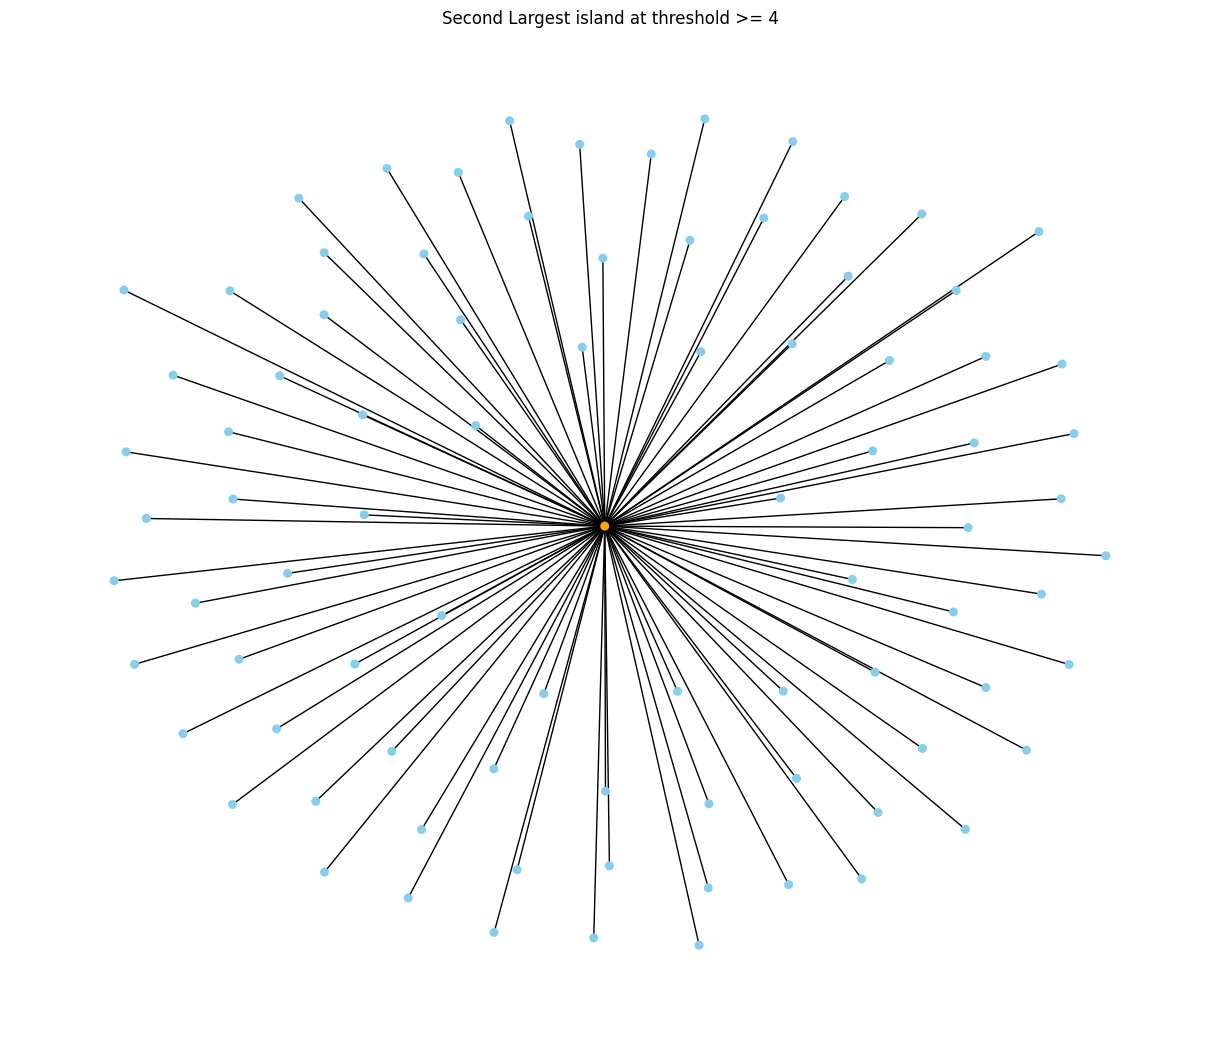

In [51]:
## Just plotting the second island  for good measure 

plt.figure(figsize=(12, 10))
pos = nx.spring_layout(second_island, seed=42)

node_colors = [
    "skyblue" if second_island.nodes[n]["bipartite"] == "users" else "orange"
    for n in second_island.nodes()
]

nx.draw(
    second_island,
    pos,
    node_color=node_colors,
    node_size=30,
    with_labels=False
)

plt.title(f"Second Largest island at threshold >= {4}")
plt.show()

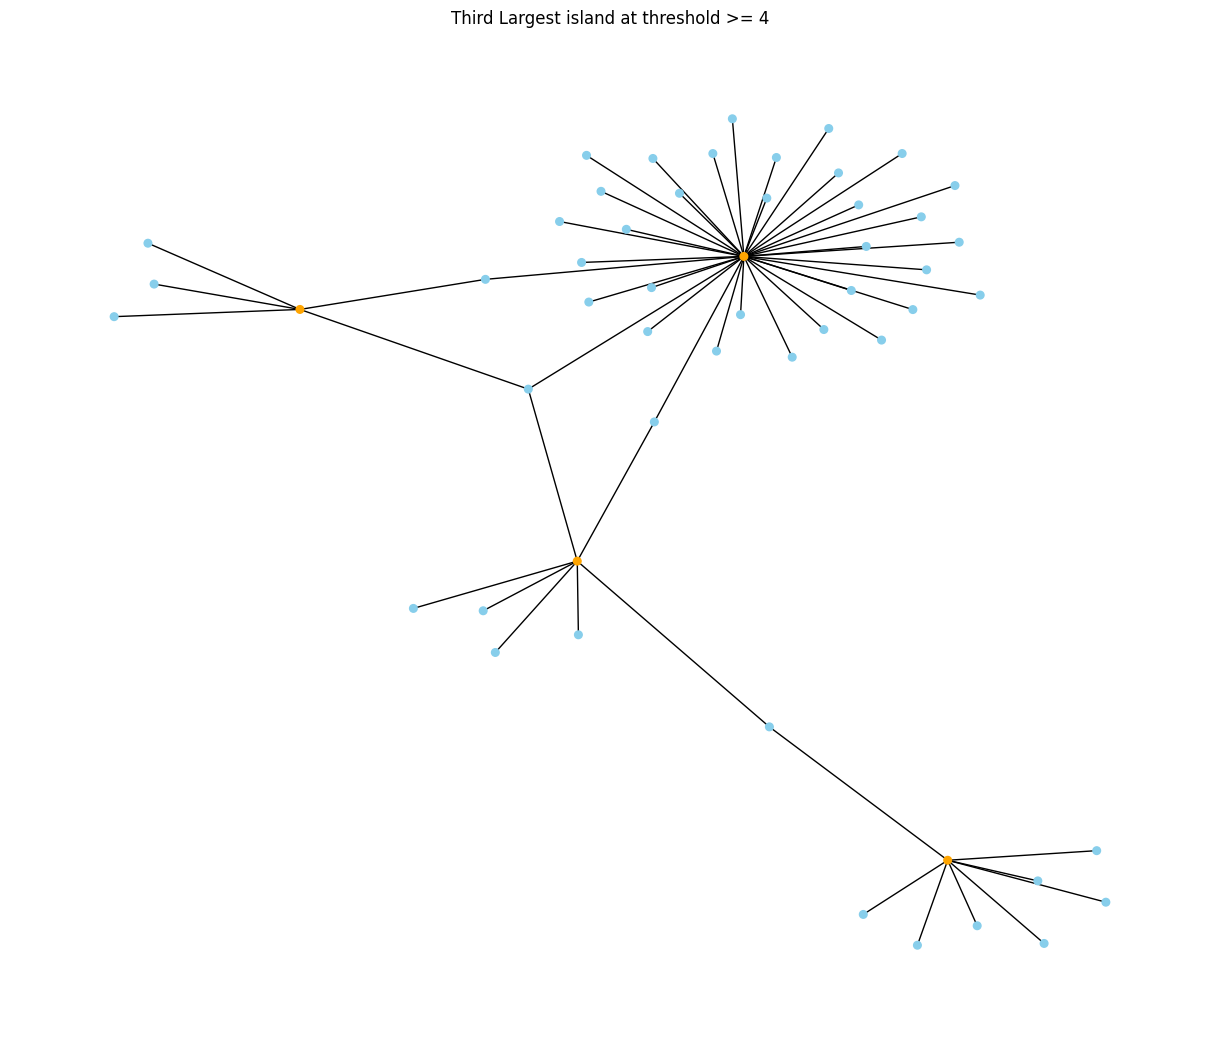

In [53]:
# Plottign the third island for good measure. 
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(third_island, seed=42)

node_colors = [
    "skyblue" if third_island.nodes[n]["bipartite"] == "users" else "orange"
    for n in third_island.nodes()
]

nx.draw(
    third_island,
    pos,
    node_color=node_colors,
    node_size=30,
    with_labels=False
)

plt.title(f"Third Largest island at threshold >= {4}")
plt.show()

In [ ]:
third_island